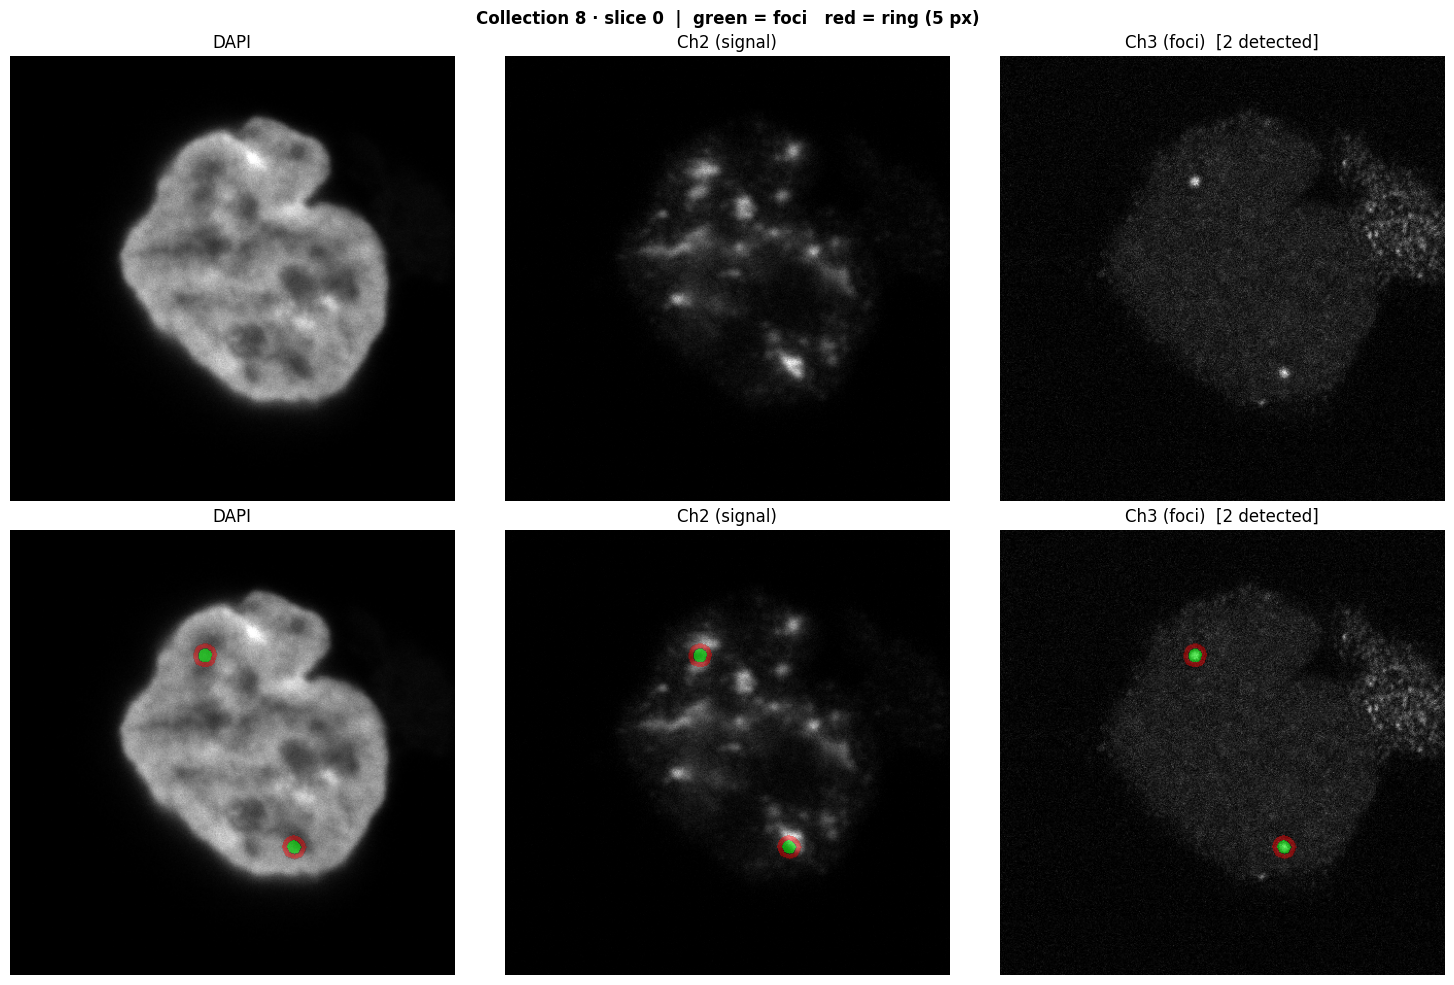

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from readlif.reader import LifFile
from skimage import filters, morphology, measure
from skimage.segmentation import clear_border


############### Parameters

# %%
LIF_PATH       = "/abyss/dlafonta/imaging/DNA_FISH/DMSO_568/DMSO_all_curated_568_clean.lif"
COLLECTION_IDX = 8           # which cell/collection
SLICE_IDX      = 0           # which z-slice
SAVE_PATH      = "FISH_segmentationMask_example_coll8slice0.png"   # None to display
DPI            = 150

GAUSSIAN_SIGMA   = 2
DILATION_PX      = 5         # ring radius

CH1_MIN_SIZE     = 100       # nucleus size / hole filter (px)
CH1_CLEAR_BORDER = True

CH3_PERCENTILE   = 97        # foci threshold (percentile within nucleus)
CH3_MIN_SIZE     = 37
CH3_MAX_SIZE     = 170       # None to disable
CH3_CLEAR_BORDER = False

############### Helper functions

def norm01(img):
    """Min–max scale to 0–1."""
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn) if mx > mn else img.astype(float)


def segment_ch1(image):
    """DAPI nuclear mask: Otsu on smoothed image, size/hole filter, clear border."""
    smooth = filters.gaussian(image, sigma=GAUSSIAN_SIGMA)
    mask   = smooth > filters.threshold_otsu(smooth)
    mask   = morphology.remove_small_objects(mask, min_size=CH1_MIN_SIZE)
    mask   = morphology.remove_small_holes(mask, area_threshold=CH1_MIN_SIZE)
    if CH1_CLEAR_BORDER:
        mask = clear_border(mask)
    return mask


def segment_ch3_in_ch1(ch3_image, ch1_mask):
    """Foci mask: percentile threshold over in-nucleus pixels, size-filtered."""
    smooth = filters.gaussian(ch3_image, sigma=GAUSSIAN_SIGMA)
    thr    = np.percentile(ch3_image[ch1_mask], CH3_PERCENTILE)
    mask   = (smooth > thr) & ch1_mask
    mask   = morphology.remove_small_objects(mask, min_size=CH3_MIN_SIZE)
    if CH3_MAX_SIZE is not None:
        labeled = measure.label(mask)
        for prop in measure.regionprops(labeled):
            if prop.area > CH3_MAX_SIZE:
                mask[labeled == prop.label] = False
    if CH3_CLEAR_BORDER:
        mask = clear_border(mask)
    return mask


def make_rgba(mask, rgb, alpha):
    """Colored transparent overlay from a boolean mask."""
    rgba = np.zeros((*mask.shape, 4))
    rgba[mask, :3] = rgb
    rgba[mask, 3]  = alpha
    return rgba


#@############## Load & segment

lif = LifFile(LIF_PATH)
img = lif.get_image(COLLECTION_IDX)

ch1 = norm01(np.array(img.get_frame(z=SLICE_IDX, t=0, c=0)).astype(float))
ch2 = norm01(np.array(img.get_frame(z=SLICE_IDX, t=0, c=1)).astype(float))
ch3 = norm01(np.array(img.get_frame(z=SLICE_IDX, t=0, c=2)).astype(float))

ch1_mask  = segment_ch1(ch1)
ch3_mask  = segment_ch3_in_ch1(ch3, ch1_mask)
n_foci    = measure.label(ch3_mask).max()

ring_mask = morphology.binary_dilation(ch3_mask, morphology.disk(DILATION_PX)) & ~ch3_mask

green = make_rgba(ch3_mask,  (0, 1, 0), 0.55)   # foci
red   = make_rgba(ring_mask, (1, 0, 0), 0.45)   # ring


#################### PLot

panels = [(ch1, "DAPI"), (ch2, "Ch2 (signal)"), (ch3, f"Ch3 (foci)  [{n_foci} detected]")]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(
    f"Collection {COLLECTION_IDX} · slice {SLICE_IDX}  "
    f"|  green = foci   red = ring ({DILATION_PX} px)",
    fontsize=12, fontweight="bold",
)

for col, (raw, ttl) in enumerate(panels):
    axes[0, col].imshow(raw, cmap="gray")
    axes[0, col].set_title(ttl)
    axes[0, col].axis("off")

    axes[1, col].imshow(raw, cmap="gray")
    axes[1, col].imshow(green)
    axes[1, col].imshow(red)
    axes[1, col].set_title(ttl)
    axes[1, col].axis("off")

plt.tight_layout()

if SAVE_PATH:
    plt.savefig(SAVE_PATH, dpi=DPI, bbox_inches="tight")
else:
    plt.show()